# 🧮 Statistical arbitrage: sector-residual mean reversion

## 🧭 tl;dr

This notebook builds a simple equity-market-neutral proxy by buying recent losers and shorting recent winners across sector ETFs. It is a transparent stand-in for residual mean-reversion strategies used in statistical arbitrage.

> Educational research only. This notebook is not financial advice.

<div style="border-left: 5px solid #2563EB; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #F8FAFC; border-radius: 8px;">
<strong>🧭 Reader guide</strong><br>
Read from top to bottom: understand the economic idea, inspect the exact rule, then compare the formal test results with the robustness checks. Finish with <strong>What went well / what went wrong</strong> to see why a backtest is evidence—not proof.
</div>

## 🧭 Context & methods

Statistical arbitrage is a family rather than one rule. A common structure is to remove common market or sector movement, then trade the residual when it looks unusually positive or negative. Sector ETFs are used here because they are easier to inspect than a survivorship-free stock universe.

### 🔧 Key assumptions

- Universe: nine sector ETFs; SPY is the benchmark and is not traded.
- Each month, the strategy buys the three recent losers and shorts the three recent winners.
- Long and short sleeves each use 50% of gross exposure, so net exposure is near zero.
- This is a low-frequency teaching proxy, not an intraday stat-arb system.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.backtest import run_backtest, split_time_series
from src.data import load_price_panel, make_demo_ohlcv
from src.portfolio import (
    dual_momentum_weights,
    inverse_volatility_weights,
    minimum_variance_weights,
    run_portfolio_backtest,
)
from src.research import metrics_for_period

# Consistent visual language across the research library.
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#CBD5E1",
    "axes.grid": True,
    "grid.color": "#CBD5E1",
    "grid.alpha": 0.35,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": "#334155",
    "xtick.color": "#475569",
    "ytick.color": "#475569",
    "legend.frameon": False,
    "figure.autolayout": True,
})


## 📦 Data

The notebook uses adjusted daily closes when available. Missing assets are removed through a common-date intersection; if the download fails, deterministic demo data keeps the code path testable without pretending the synthetic results are market evidence.

In [2]:
USE_DEMO_DATA = False
TRANSACTION_COST_BPS = 10
TICKERS = ['SPY', 'XLE', 'XLF', 'XLK', 'XLI', 'XLP', 'XLU', 'XLV', 'XLY', 'XLB']

if USE_DEMO_DATA:
    close = pd.concat([make_demo_ohlcv(periods=5_000, seed=120, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=121, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=122, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=123, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=124, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=125, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=126, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=127, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=128, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=129, start='2006-01-01')['close'].rename(t)], axis=1)
else:
    try:
        close = load_price_panel(TICKERS, '2015-01-01', '2026-01-01')
    except Exception as exc:
        print(f'Live download unavailable ({type(exc).__name__}: {exc}); using deterministic demo data.')
        close = pd.concat([make_demo_ohlcv(periods=5_000, seed=120, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=121, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=122, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=123, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=124, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=125, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=126, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=127, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=128, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=129, start='2006-01-01')['close'].rename(t)], axis=1)

close = close.dropna(how='any')
splits = split_time_series(close, train_fraction=0.60, validation_fraction=0.20)
benchmark_returns = close['SPY'].pct_change().fillna(0.0)
print(f'Data: {close.index.min().date()} through {close.index.max().date()} ({len(close):,} common trading days)')
print('Assets:', ', '.join(close.columns))


Data: 2015-01-02 through 2025-12-31 (2,766 common trading days)
Assets: SPY, XLB, XLE, XLF, XLI, XLK, XLP, XLU, XLV, XLY


## 📜 Strategy rules

1. Measure each sector ETF’s trailing 21-day return.
2. Long the three weakest sectors and short the three strongest sectors.
3. Rebalance monthly and keep the book close to dollar-neutral.
4. Shift weights by one bar before returns are applied.

The contrarian direction is intentional: this notebook tests short-horizon residual mean reversion, not intermediate-horizon momentum.

In [3]:
def sector_residual_weights(panel, lookback=21, long_n=3, short_n=3):
    assets = [c for c in panel.columns if c != 'SPY']
    score = panel[assets].pct_change(lookback).shift(1)
    month_start = pd.Series(panel.index.to_period('M'), index=panel.index).ne(pd.Series(panel.index.to_period('M'), index=panel.index).shift(1)).to_numpy()
    candidates = pd.DataFrame(0.0, index=panel.index, columns=panel.columns)
    for timestamp in panel.index[month_start]:
        valid = score.loc[timestamp].dropna()
        if len(valid) < long_n + short_n:
            continue
        losers = valid.nsmallest(short_n).index
        winners = valid.nlargest(long_n).index
        candidates.loc[timestamp, losers] = 0.50 / len(losers)
        candidates.loc[timestamp, winners] = -0.50 / len(winners)
    return candidates.ffill().fillna(0.0)

weights = sector_residual_weights(close)


## 📈 Formal test results

The untouched final 20% of the chronological sample is used for the headline table. Parameters are defined before reading the final test outputs.

In [4]:
result = run_portfolio_backtest(
    close if 'weights' in locals() and set(weights.columns) == set(close.columns) else close,
    weights,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    benchmark_returns=benchmark_returns,
)
test_metrics = metrics_for_period(result, splits['test'].index)
test_table = pd.DataFrame([test_metrics], index=['Statistical arbitrage: sector-residual mean reversion'])
format_map = {
    'annualized_return': '{:.2%}', 'annualized_volatility': '{:.2%}', 'sharpe_ratio': '{:.2f}',
    'sortino_ratio': '{:.2f}', 'max_drawdown': '{:.2%}', 'calmar_ratio': '{:.2f}',
    'win_rate': '{:.2%}', 'annualized_turnover': '{:.2f}', 'number_of_trades': '{:.0f}',
    'total_return_after_costs': '{:.2%}', 'benchmark_relative_return': '{:.2%}',
}
display(test_table.style.format(format_map))
print('Formal test findings:')
print(f"  Sharpe={test_metrics['sharpe_ratio']:.2f} | annualized return={test_metrics['annualized_return']:.2%} | max drawdown={test_metrics['max_drawdown']:.2%}")


,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate,annualized_turnover,number_of_trades,total_return_after_costs,benchmark_total_return,benchmark_relative_return
Statistical arbitrage: sector-residual mean reversion,-1.60%,1.38%,-1.16,-1.51,-5.21%,-0.31,42.31%,23.65,52,-3.48%,0.609052,-64.38%


Formal test findings:
  Sharpe=-1.16 | annualized return=-1.60% | max drawdown=-5.21%


## 📊 Equity curve and drawdown

The chart normalizes the strategy and SPY benchmark to one at the start of the formal test period. Drawdown is shown below it so a smooth return path is not mistaken for low risk.

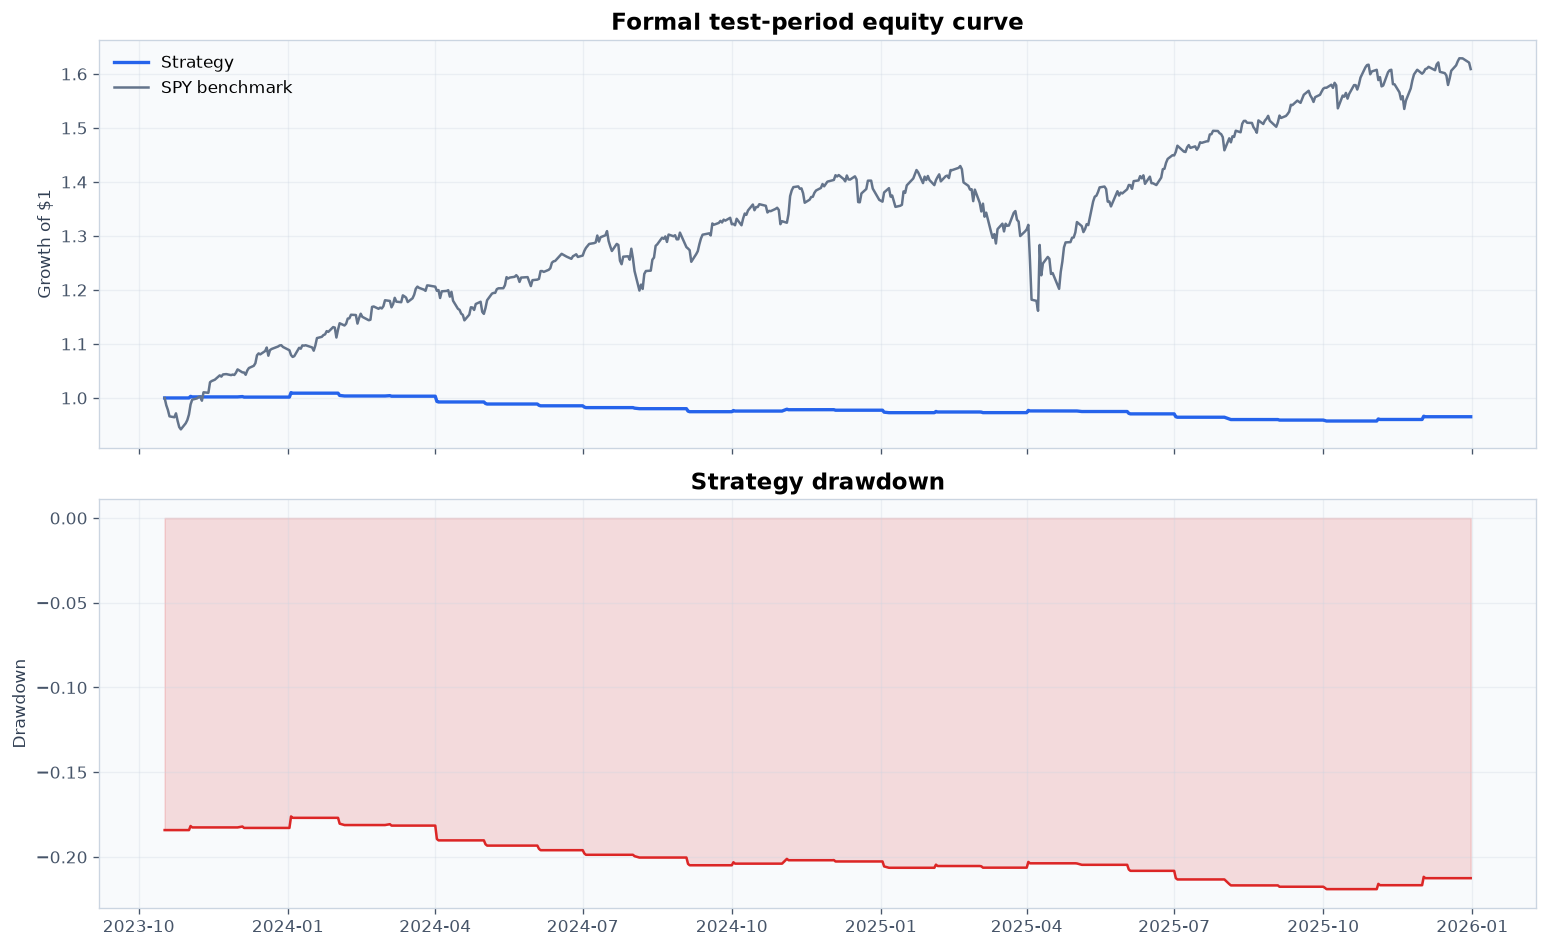

In [5]:
test_index = splits['test'].index
equity = result.frame.loc[test_index, 'equity']
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(equity.index, equity / equity.iloc[0], color='#2563EB', linewidth=2, label='Strategy')
benchmark_curve = (1.0 + result.frame.loc[test_index, 'benchmark_returns']).cumprod()
axes[0].plot(benchmark_curve.index, benchmark_curve, color='#64748B', linewidth=1.5, label='SPY benchmark')
axes[0].set_title('Formal test-period equity curve')
axes[0].set_ylabel('Growth of $1')
axes[0].legend()
axes[0].grid(alpha=0.3)
drawdown = result.frame.loc[test_index, 'drawdown']
axes[1].plot(drawdown.index, drawdown, color='#DC2626', linewidth=1.5)
axes[1].fill_between(drawdown.index, drawdown, 0, color='#DC2626', alpha=0.15)
axes[1].set_title('Strategy drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].grid(alpha=0.3)
plt.show()


## 🛡️ Robustness and crisis diagnostics

These checks are descriptive. Cost sensitivity shows how much implementation friction matters; crisis windows show failure modes and are not additional untouched test sets.

In [6]:
cost_rows = []
for cost_bps in [0, 5, 10, 25, 50]:
    candidate = run_candidate(cost_bps) if 'run_candidate' in locals() else None
    if candidate is None:
        if 'weights' in locals():
            candidate = run_portfolio_backtest(close, weights, transaction_cost_bps=cost_bps, benchmark_returns=benchmark_returns)
        else:
            candidate = run_backtest(close.iloc[:, 0], target, transaction_cost_bps=cost_bps, benchmark_returns=benchmark_returns)
    metrics = metrics_for_period(candidate, splits['test'].index)
    cost_rows.append({'cost_bps': cost_bps, 'test_return': metrics['annualized_return'], 'test_sharpe': metrics['sharpe_ratio'], 'max_drawdown': metrics['max_drawdown'], 'turnover': metrics['annualized_turnover']})
cost_table = pd.DataFrame(cost_rows).set_index('cost_bps')
display(cost_table.style.format({'test_return': '{:.2%}', 'test_sharpe': '{:.2f}', 'max_drawdown': '{:.2%}', 'turnover': '{:.2f}'}))

stress_windows = {
    'Global Financial Crisis': ('2007-10-01', '2009-03-31'),
    'COVID shock': ('2020-02-19', '2020-03-23'),
    '2022 inflation/rates shock': ('2022-01-03', '2022-10-14'),
}
stress_rows = []
for window, (start, end) in stress_windows.items():
    index = close.loc[start:end].index
    if len(index) == 0:
        continue
    returns = result.frame.loc[index, 'net_returns']
    path = (1.0 + returns).cumprod()
    stress_rows.append({'window': window, 'return': path.iloc[-1] - 1.0, 'max_drawdown': (path / path.cummax() - 1.0).min()})
stress_table = pd.DataFrame(stress_rows).set_index('window')
display(stress_table.style.format({'return': '{:.2%}', 'max_drawdown': '{:.2%}'}))


,test_return,test_sharpe,max_drawdown,turnover
cost_bps,,,,
0,0.76%,0.57,-1.84%,23.65
5,-0.43%,-0.31,-3.14%,23.65
10,-1.60%,-1.16,-5.21%,23.65
25,-5.03%,-3.06,-11.14%,23.65
50,-10.50%,-4.34,-21.65%,23.65


,return,max_drawdown
window,,
COVID shock,-0.48%,-0.48%
2022 inflation/rates shock,-1.22%,-2.20%


## ⚖️ What went well / what went wrong

**What went well:** The market-neutral construction separates a strategy return from simply owning equities and makes turnover, concentration, and gross exposure visible.

**What went wrong:** Short-term reversals are fragile: costs, spreads, borrow, sector shocks, and crowded exits can overwhelm the signal. Sector ETFs are not stock-level residuals and a nine-ETF universe is far narrower than a professional stat-arb book.

**Research judgment:** The published research used broad equity universes and more sophisticated residual models. Treat this as a teaching proxy that tests the mechanism, not the paper’s headline performance.

> The displayed metrics are sample-specific proxy results. They should be interpreted alongside costs, turnover, stress windows, and implementation gaps.